# EIB Green-Lending Regional Pipeline

This notebook walks through a small, reproducible pipeline that reproduces a regional green-finance data workflow: it takes European Investment Bank (EIB) green-lending project data, extracts key figures from a few project appraisal PDFs, assigns each investment a NUTS2/NUTS3 region via a spatial join, merges it with a Eurostat-style regional indicator, and produces a choropleth map plus an analysis-ready regional panel dataset.

**Honesty note:** this notebook currently runs on generated synthetic sample data with the correct schema (see `src/generate_synthetic.py`). No real EIB, GISCO or Eurostat data has been downloaded yet. Real data can be dropped into `data/real/` and the pipeline pointed at it in Phase 2 - see the README for details. No statistical "findings" are claimed anywhere in this notebook; every number below is either synthetic or a plain descriptive aggregate of that synthetic data.

**What this demonstrates:**
- constructing an analysis-ready dataset from heterogeneous sources (a project-level CSV and PDF documents)
- systematic extraction of key financial variables from PDF text
- spatial joins to assign consistent geographic identifiers (NUTS2/NUTS3)
- merging project-level data onto a regional indicator panel by region and year
- visualising the resulting regional distribution


In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from IPython.display import Image, display

%matplotlib inline


## Stage 0 - Generate synthetic sample data

Everything below is generated with a fixed random seed, so re-running this cell reproduces identical output. This is the only stage that writes to `data/sample/` - every other stage just reads from it.


In [2]:
from src import generate_synthetic

generate_synthetic.main()


Generating synthetic lending data...
  wrote 200 rows to C:\Users\hp\Desktop\WORK\eib-green-lending\data\sample\lending.csv
Generating synthetic NUTS boundaries...
  wrote 30 regions to C:\Users\hp\Desktop\WORK\eib-green-lending\data\sample\nuts_boundaries.geojson
Generating synthetic regional indicators...
  wrote 100 rows to C:\Users\hp\Desktop\WORK\eib-green-lending\data\sample\regional_indicators.csv
Generating synthetic project PDFs...
  wrote 5 PDFs to C:\Users\hp\Desktop\WORK\eib-green-lending\data\sample\pdfs
Done.


## Stage 1 - Load lending data

Loads the EIB-style project CSV, validates its schema and coordinate ranges, and casts columns to sensible dtypes. `climate_action` marks which projects are climate-relevant, which lets us filter the dataset down for later stages.


In [3]:
from src.load_lending import load_lending_data, filter_climate_action

lending = load_lending_data()
print(f"{len(lending)} projects loaded")
lending.head()


200 projects loaded


,project_id,project_name,country,city,lat,lon,signed_amount_eur,sector,climate_action,signed_year
0,EIB-2014-0000,"Energy Efficiency Facility, Porto",PT,Porto,41.6879,-9.0551,54700000.0,Energy Efficiency,True,2014
1,EIB-2018-0001,"Water Management Facility, Marseille",FR,Marseille,49.8533,1.3327,52400000.0,Water Management,True,2018
2,EIB-2014-0002,Energy Efficiency Investment Programme - Cluj-...,RO,Cluj-Napoca,47.0933,21.6531,48300000.0,Energy Efficiency,True,2014
3,EIB-2023-0003,Water Management Investment Programme - Dublin,IE,Dublin,54.1130,-6.5848,39100000.0,Water Management,True,2023
4,EIB-2021-0004,Clean Transport Investment Programme - Athens,EL,Athens,41.1343,24.7430,34900000.0,Clean Transport,True,2021


In [4]:
climate_lending = filter_climate_action(lending)
print(f"Climate-relevant: {len(climate_lending)} / {len(lending)} projects")
print(f"Total signed amount (all projects): EUR {lending['signed_amount_eur'].sum():,.0f}")
print(f"Total signed amount (climate-relevant only): EUR {climate_lending['signed_amount_eur'].sum():,.0f}")


Climate-relevant: 157 / 200 projects
Total signed amount (all projects): EUR 11,751,800,000
Total signed amount (climate-relevant only): EUR 9,250,800,000


## Stage 2 - Extract figures from project appraisal PDFs

A handful of synthetic EIB-style project appraisal PDFs live in `data/sample/pdfs/`. This stage uses `pdfplumber` to pull text out of each PDF and regex out three labelled EUR figures: total project cost, EIB finance, and co-financing. This is a small demonstration of the extraction machinery, not a general-purpose PDF parser.


In [5]:
from src.extract_pdf import extract_all_pdfs

pdf_fields = extract_all_pdfs()
pdf_fields


,project_id,source_file,total_project_cost_eur,eib_finance_eur,cofinancing_eur
0,EIB-2016-0156,EIB-2016-0156.pdf,226200000.0,89700000.0,136500000.0
1,EIB-2017-0077,EIB-2017-0077.pdf,140400000.0,53100000.0,87300000.0
2,EIB-2018-0180,EIB-2018-0180.pdf,164100000.0,61900000.0,102200000.0
3,EIB-2023-0059,EIB-2023-0059.pdf,245000000.0,95400000.0,149600000.0
4,EIB-2023-0108,EIB-2023-0108.pdf,72400000.0,22800000.0,49600000.0


## Stage 3 - Assign NUTS2/NUTS3 regions via spatial join

Each project's `(lat, lon)` point is joined against a set of NUTS boundary polygons using `geopandas`. The boundaries file is synthetic (simple rectangles standing in for real GISCO NUTS geometries) but has the same structure as the real thing: it contains both NUTS2 and NUTS3 features distinguished by `LEVL_CODE`, and every geometry is explicitly in EPSG:4326 (WGS84 lat/lon), matching the CRS the project points are built in.


In [6]:
from src.assign_nuts import assign_nuts_regions, load_nuts_boundaries

nuts_gdf = load_nuts_boundaries()
lending_with_nuts = assign_nuts_regions(lending, nuts_gdf)

unmatched = lending_with_nuts["nuts2_code"].isna().sum()
print(f"Unmatched projects: {unmatched} / {len(lending_with_nuts)}")
lending_with_nuts[["project_id", "country", "lat", "lon", "nuts2_code", "nuts3_code"]].head()


Unmatched projects: 0 / 200


,project_id,country,lat,lon,nuts2_code,nuts3_code
0,EIB-2014-0000,PT,41.6879,-9.0551,PT10,PT101
1,EIB-2018-0001,FR,49.8533,1.3327,FR10,FR101
2,EIB-2014-0002,RO,47.0933,21.6531,RO10,RO101
3,EIB-2023-0003,IE,54.1130,-6.5848,IE10,IE102
4,EIB-2021-0004,EL,41.1343,24.7430,EL10,EL102


## Stage 4 - Merge with a Eurostat-style regional indicator

The NUTS-assigned lending data is aggregated up to a NUTS2 x year panel (total signed amount, climate-relevant amount, project counts) and left-joined onto a synthetic Eurostat-style regional indicator table (`gfcf_eur_millions`, standing in for gross fixed capital formation). Starting from the indicator table means every region-year is kept in the panel, including the ones with no recorded lending activity - which matters if this panel is ever used for the difference-in-differences / event-study work described in the target role.


In [7]:
from src.merge_regional import load_regional_indicators, merge_with_regional_indicator

regional = load_regional_indicators()
panel = merge_with_regional_indicator(lending_with_nuts, regional, nuts_gdf)

print(f"Panel shape: {panel.shape[0]} rows ({panel['nuts_code'].nunique()} regions x {panel['year'].nunique()} years)")
print(f"Region-years with zero recorded lending: {(panel['num_projects'] == 0).sum()} / {len(panel)}")
panel.head(10)


Panel shape: 100 rows (10 regions x 10 years)
Region-years with zero recorded lending: 16 / 100


,nuts_code,nuts_name,year,num_projects,total_signed_amount_eur,climate_signed_amount_eur,climate_action_share,gfcf_eur_millions
0,DE10,Germany (synthetic NUTS2),2014,3,102700000.0,102700000.0,1.000000,38626.2
1,DE10,Germany (synthetic NUTS2),2015,0,0.0,0.0,NaN,39195.2
2,DE10,Germany (synthetic NUTS2),2016,2,179600000.0,179600000.0,1.000000,34493.4
3,DE10,Germany (synthetic NUTS2),2017,3,177700000.0,177700000.0,1.000000,39196.7
4,DE10,Germany (synthetic NUTS2),2018,5,163500000.0,132500000.0,0.810398,37436.9
5,DE10,Germany (synthetic NUTS2),2019,1,235000000.0,235000000.0,1.000000,41918.3
6,DE10,Germany (synthetic NUTS2),2020,1,52400000.0,52400000.0,1.000000,37177.0
7,DE10,Germany (synthetic NUTS2),2021,1,60400000.0,60400000.0,1.000000,43657.3
8,DE10,Germany (synthetic NUTS2),2022,0,0.0,0.0,NaN,43769.4
9,DE10,Germany (synthetic NUTS2),2023,4,146500000.0,95400000.0,0.651195,39657.9


In [8]:
from src.merge_regional import DEFAULT_OUTPUT_PATH

DEFAULT_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
panel.to_csv(DEFAULT_OUTPUT_PATH, index=False)
print(f"Saved {DEFAULT_OUTPUT_PATH}")


Saved C:\Users\hp\Desktop\WORK\eib-green-lending\outputs\merged_panel.csv


## Stage 5 - Visualise

Three views of the same underlying data: a choropleth of total climate-relevant lending intensity per NUTS2 region, a bar chart of total lending by sector, and a line chart of lending over time (all sectors vs. climate-relevant only).


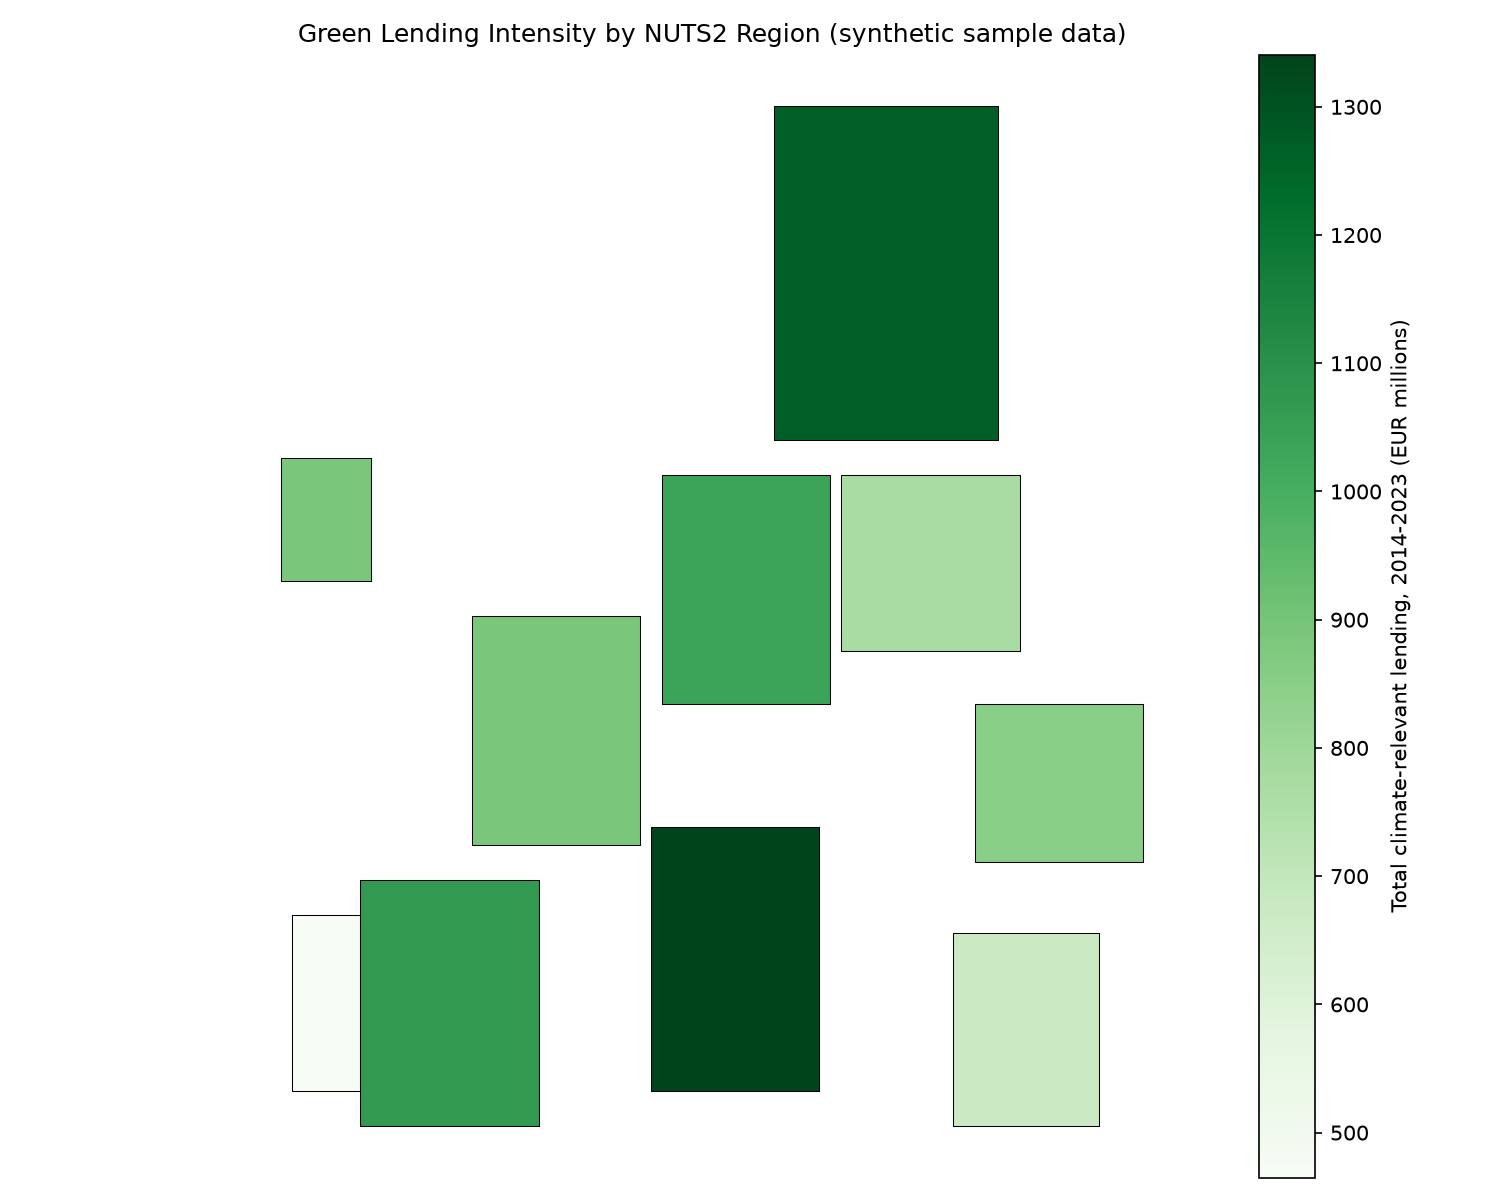

In [9]:
from src.visualise import (
    CHOROPLETH_PATH, BY_SECTOR_PATH, OVER_TIME_PATH,
    plot_choropleth, plot_by_sector, plot_over_time,
)

plot_choropleth(panel, nuts_gdf)
display(Image(filename=str(CHOROPLETH_PATH)))


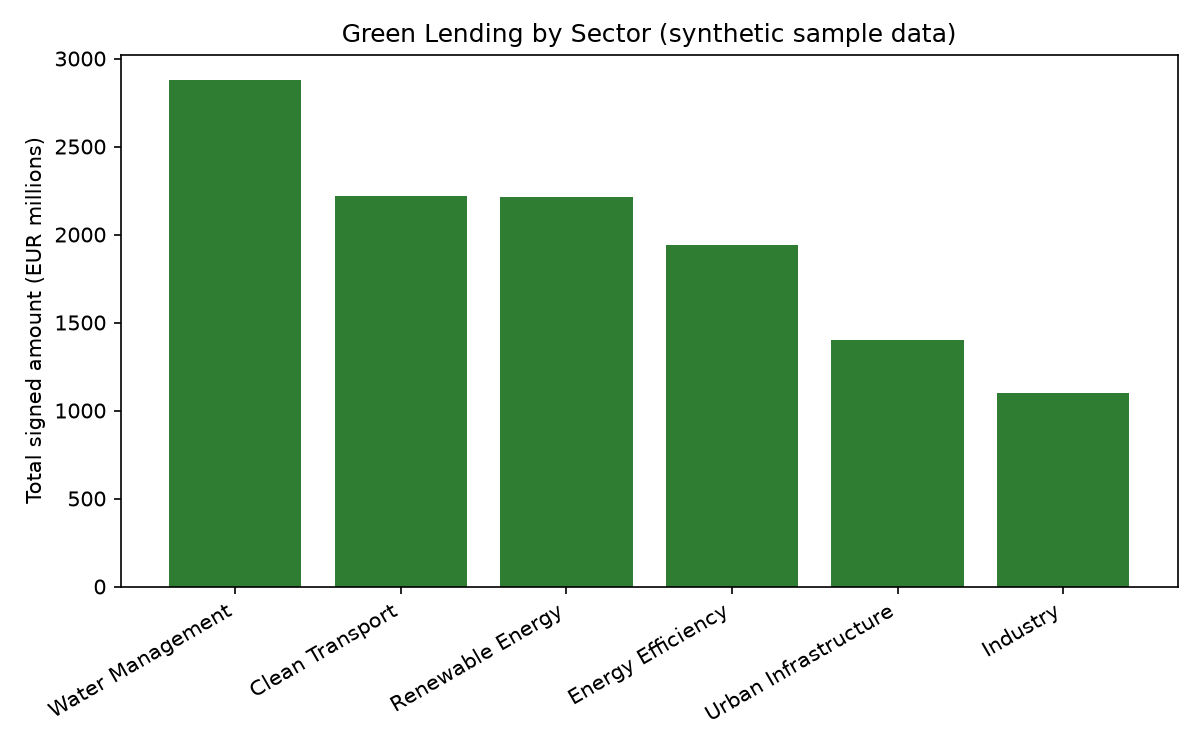

In [10]:
plot_by_sector(lending)
display(Image(filename=str(BY_SECTOR_PATH)))


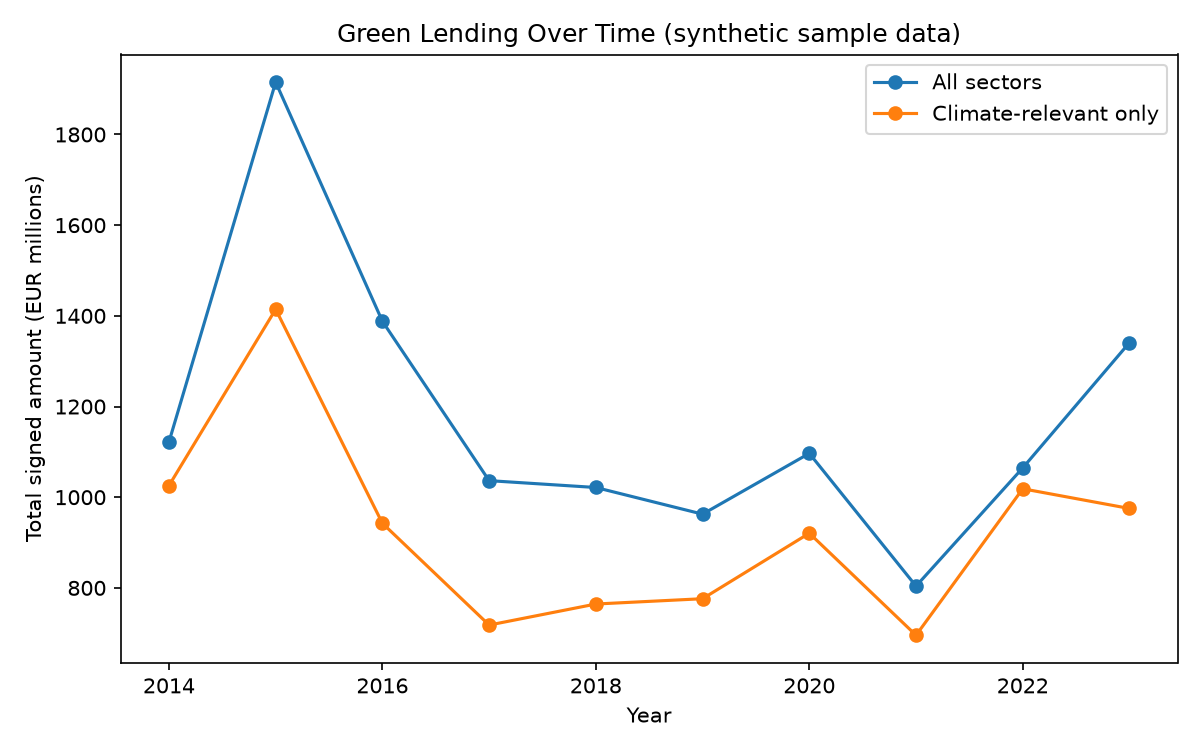

In [11]:
plot_over_time(lending)
display(Image(filename=str(OVER_TIME_PATH)))


## Summary

This notebook ran the full pipeline end-to-end on synthetic sample data: load -> extract -> spatial join -> regional merge -> visualise, producing `outputs/merged_panel.csv` and three PNGs under `outputs/`. See the README for the Phase 2 plan to swap in real EIB project data, real GISCO NUTS boundaries, and real Eurostat regional accounts.
